In [1]:
from google.colab import drive
import os

if not os.path.ismount("/content/drive"):
    try:
        drive.mount("/content/drive", force_remount=True)
    except Exception as e:
        print("Mount note:", e)

Mounted at /content/drive


In [2]:
# ============================================================
# DIRISA SDC 2026 - Teams Qualification
# Notebook 05: Interactive Deployment
# Type: Interactive notebook (ipywidgets)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from ipywidgets import (
    interact, interactive_output, Dropdown, SelectMultiple,
    IntSlider, Checkbox, VBox, HBox, Output, HTML, Button
)
from IPython.display import display, clear_output, FileLink

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

DATA = Path("/content/drive/MyDrive/dirisa-sdc/processed")
CHARTS = DATA / "charts"
CHARTS.mkdir(parents=True, exist_ok=True)

print("Setup complete.")

Setup complete.


In [3]:
df = pd.read_csv(DATA / "municipality_clusters_full.csv")
priority = pd.read_csv(DATA / "priority_municipalities.csv")

print("df shape:", df.shape)
print("priority shape:", priority.shape)
print()
print("Columns:", df.columns.tolist())
print()
print(df.head(3))

df shape: (33, 8)
priority shape: (33, 7)

Columns: ['mdb_code', 'municipality', 'district', 'cluster_name', 'youth_gap_2026', 'youth_registration_rate_2026', 'youth_registration_change_pct', 'youth_disengagement_risk']

  mdb_code      municipality        district         cluster_name  \
0    EC124         Amahlathi        Amathole    High gap / Stable   
1    EC102  Blue Crane Route  Sarah Baartman  High gap / Widening   
2      BUF      Buffalo City    Buffalo City    High gap / Stable   

   youth_gap_2026  youth_registration_rate_2026  \
0        0.249797                      0.750203   
1        0.341675                      0.658325   
2        0.255109                      0.744891   

   youth_registration_change_pct  youth_disengagement_risk  
0                     -10.024043                  0.808876  
1                     -11.027062                  0.600000  
2                     -10.024043                  0.818205  


In [4]:
# ============================================================
# Section 1: Project header
# ============================================================

display(HTML("""
<div style="background:#2c3e50; padding:20px; border-radius:8px; color:white;">
  <h1 style="margin:0;">Youth Voter Disengagement — Eastern Cape</h1>
  <p style="margin:5px 0 0 0; font-size:14px;">
    DIRISA SDC 2026 · Teams Qualification · Angle A
  </p>
  <p style="margin:5px 0 0 0; font-size:13px; opacity:0.85;">
    Which municipalities exhibit the widest and fastest-growing gap
    between eligible youth and registered youth voters?
  </p>
</div>
"""))

HTML(value='\n<div style="background:#2c3e50; padding:20px; border-radius:8px; color:white;">\n  <h1 style="ma…

In [5]:
# ============================================================
# Section 2: Global summary stats
# ============================================================

total_muni = len(df)
widest = df.loc[df["youth_gap_2026"].idxmax()]
avg_gap = df["youth_gap_2026"].mean() * 100

display(HTML(f"""
<div style="display:flex; gap:15px; margin:15px 0;">
  <div style="flex:1; background:#ecf0f1; padding:15px; border-radius:6px;">
    <div style="font-size:12px; color:#7f8c8d;">Municipalities analysed</div>
    <div style="font-size:24px; font-weight:bold;">{total_muni}</div>
  </div>
  <div style="flex:1; background:#ecf0f1; padding:15px; border-radius:6px;">
    <div style="font-size:12px; color:#7f8c8d;">Provincial mean gap</div>
    <div style="font-size:24px; font-weight:bold;">{avg_gap:.1f}%</div>
  </div>
  <div style="flex:1; background:#ecf0f1; padding:15px; border-radius:6px;">
    <div style="font-size:12px; color:#7f8c8d;">Widest gap</div>
    <div style="font-size:18px; font-weight:bold;">{widest['municipality']}</div>
    <div style="font-size:14px; color:#c0392b;">{widest['youth_gap_2026']*100:.1f}%</div>
  </div>
</div>
"""))

HTML(value='\n<div style="display:flex; gap:15px; margin:15px 0;">\n  <div style="flex:1; background:#ecf0f1; …

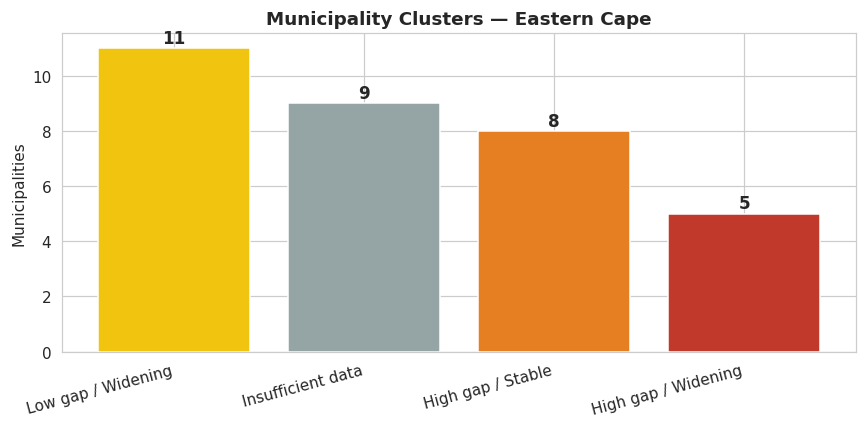

In [6]:
# ============================================================
# Section 3: Cluster distribution
# ============================================================

cluster_counts = df["cluster_name"].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
colors = {"High gap / Widening": "#c0392b",
          "High gap / Stable":   "#e67e22",
          "Low gap / Widening":   "#f1c40f",
          "Low gap / Stable":     "#27ae60",
          "Insufficient data":    "#95a5a6"}

bars = ax.bar(cluster_counts.index,
              cluster_counts.values,
              color=[colors.get(c, "grey") for c in cluster_counts.index])

for bar, val in zip(bars, cluster_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            str(val), ha="center", fontsize=11, fontweight="bold")

ax.set_ylabel("Municipalities")
ax.set_title("Municipality Clusters — Eastern Cape", fontweight="bold")
plt.xticks(rotation=15, ha="right")

plt.tight_layout()
plt.savefig(CHARTS / "09_cluster_distribution.png", bbox_inches="tight")
plt.show()

In [7]:
# ============================================================
# Section 4: Interactive municipality drill-down
# ============================================================

muni_dropdown = Dropdown(
    options=sorted(df["municipality"].unique()),
    value=sorted(df["municipality"].unique())[0],
    description="Municipality:",
    style={"description_width": "initial"},
    layout={"width": "500px"}
)

out_detail = Output()

def show_municipality(muni_name):
    with out_detail:
        clear_output(wait=True)
        row = df[df["municipality"] == muni_name].iloc[0]

        # Metric cards
        display(HTML(f"""
        <div style="display:flex; gap:15px; margin:15px 0;">
          <div style="flex:1; background:#fdf2f2; padding:15px; border-radius:6px; border-left:4px solid #c0392b;">
            <div style="font-size:12px; color:#7f8c8d;">Youth Gap 2026</div>
            <div style="font-size:22px; font-weight:bold;">{row['youth_gap_2026']*100:.1f}%</div>
          </div>
          <div style="flex:1; background:#eef9f0; padding:15px; border-radius:6px; border-left:4px solid #27ae60;">
            <div style="font-size:12px; color:#7f8c8d;">Youth Registration Rate</div>
            <div style="font-size:22px; font-weight:bold;">{row['youth_registration_rate_2026']*100:.1f}%</div>
          </div>
          <div style="flex:1; background:#f4f6f7; padding:15px; border-radius:6px; border-left:4px solid #2c3e50;">
            <div style="font-size:12px; color:#7f8c8d;">District</div>
            <div style="font-size:16px; font-weight:bold;">{row['district']}</div>
          </div>
        </div>
        """))

        # Cluster badge
        cluster_color = colors.get(row["cluster_name"], "#95a5a6")
        display(HTML(f"""
        <div style="background:{cluster_color}; color:white; padding:10px 15px;
                    border-radius:6px; display:inline-block; font-weight:bold;">
          Cluster: {row['cluster_name']}
        </div>
        """))

        # Detail table
        detail_df = pd.DataFrame({
            "Metric": ["Eligible youth (Census 2022)",
                       "Registered youth (IEC 2026)",
                       "Youth gap 2026",
                       "Youth registration rate 2026",
                       "District trend 2016→2021",
                       "Composite risk score"],
            "Value": [
                f"{row['youth_pop_20_34_2022']:,.0f}",
                f"{row['registered_youth_total']:,.0f}",
                f"{row['youth_gap_2026']*100:.2f}%",
                f"{row['youth_registration_rate_2026']*100:.2f}%",
                f"{row['youth_registration_change_pct']:.2f}%" if pd.notna(row['youth_registration_change_pct']) else "N/A",
                f"{row['youth_disengagement_risk']:.3f}" if pd.notna(row['youth_disengagement_risk']) else "N/A",
            ]
        })
        display(detail_df)

# Wire it up
interact(show_municipality, muni_name=muni_dropdown);

interactive(children=(Dropdown(description='Municipality:', layout=Layout(width='500px'), options=('Amahlathi'…

In [8]:
# ============================================================
# Section 5: Priority table with cluster filter
# ============================================================

cluster_filter = SelectMultiple(
    options=sorted(df["cluster_name"].unique()),
    value=sorted(df["cluster_name"].unique()),
    description="Show clusters:",
    style={"description_width": "initial"},
    layout={"width": "500px", "height": "100px"}
)

out_table = Output()

def show_priority(clusters):
    with out_table:
        clear_output(wait=True)
        filtered = df[df["cluster_name"].isin(clusters)]
        filtered = filtered.sort_values("youth_gap_2026", ascending=False)

        display(HTML(f"<b>{len(filtered)} municipalities match</b>"))
        display(filtered[[
            "mdb_code", "municipality", "district",
            "cluster_name", "youth_gap_2026",
            "youth_registration_rate_2026",
            "youth_registration_change_pct"
        ]].style.format({
            "youth_gap_2026": "{:.1%}",
            "youth_registration_rate_2026": "{:.1%}",
            "youth_registration_change_pct": "{:.2f}%",
        }).background_gradient(subset=["youth_gap_2026"], cmap="Reds"))

interact(show_priority, clusters=cluster_filter);

interactive(children=(SelectMultiple(description='Show clusters:', index=(0, 1, 2, 3), layout=Layout(height='1…

In [9]:
# ============================================================
# Section 6: Export priority list
# ============================================================

export_path = DATA / "interactive_export_priority.csv"
df.sort_values("youth_disengagement_risk", ascending=False).to_csv(export_path, index=False)

display(HTML(f"""
<div style="background:#eef9f0; padding:12px; border-radius:6px; margin:10px 0;">
  <b>Export ready:</b> Full municipality table saved to
  <code>{export_path.name}</code>
</div>
"""))

display(FileLink(str(export_path)))

HTML(value='\n<div style="background:#eef9f0; padding:12px; border-radius:6px; margin:10px 0;">\n  <b>Export r…

/content/drive/MyDrive/dirisa-sdc/processed/interactive_export_priority.csv

In [10]:
# ============================================================
# Section 7: Methodology and limitations
# ============================================================

display(HTML("""
<div style="background:#f4f6f7; padding:20px; border-radius:6px; margin:20px 0;">
  <h3 style="margin-top:0;">Methodology</h3>
  <ul>
    <li><b>Data sources:</b> IEC Voter Registration Statistics, Census 2022, IEC 2021 Municipal Elections Report</li>
    <li><b>Youth definition:</b> 18–39 IEC registration bands (proxy for 18–34)</li>
    <li><b>Gap formula:</b> (eligible_youth − registered_youth) / eligible_youth</li>
    <li><b>Hybrid scoring:</b> 60% weight on 2026 gap, 40% on district-level trend (2016→2021)</li>
    <li><b>Model:</b> K-means clustering (k=4), silhouette = 0.371</li>
    <li><b>Regression finding:</b> CV R² = −2.213 (features do not linearly predict gap)</li>
  </ul>

  <h3>Limitations</h3>
  <ul>
    <li>IEC dashboard requires scraping; per-municipality extraction is manual</li>
    <li>Census age bands (15–34) do not align with IEC bands (18–39)</li>
    <li>Metros (Buffalo City, Nelson Mandela Bay) lack district trend data</li>
    <li>2026 registration surge may not translate to turnout</li>
    <li>Analysis is currently Eastern Cape only (pilot province)</li>
  </ul>
</div>
"""))

HTML(value='\n<div style="background:#f4f6f7; padding:20px; border-radius:6px; margin:20px 0;">\n  <h3 style="…

In [11]:
display(HTML("""
<div style="text-align:center; padding:20px; color:#7f8c8d; font-size:12px;">
  DIRISA SDC 2026 · Teams Qualification · Eastern Cape pilot
</div>
"""))

HTML(value='\n<div style="text-align:center; padding:20px; color:#7f8c8d; font-size:12px;">\n  DIRISA SDC 2026…